In [54]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

def f_constant0(input):
    return 0
def f_constant1(input):
    return 1
def f_balanced0(input):
    return 0 if input == 0 else 1
def f_balanced1(input):
    return 1 if input == 0 else 0

#Oracle blackbox
def create_oracle(function_choice):
    if function_choice == 0:
        return
    elif function_choice == 1:
        qc.cx(0,1)
    elif function_choice == 2:
        qc.cx(0,1)
        qc.x(1)
    else:
        qc.x(1)


qc = QuantumCircuit(2,1)


In [55]:
qc.h(0)
qc.x(1)
qc.h(1)
qc.save_statevector(label="|α⟩")

print("""
Choose the oracle:

0 - Constant 0
1 - Constant 1
2 - Balanced (Identity)
3 - Balanced (NOT)
""")

function_choice = int(input("Enter your choice (0-3): "))

create_oracle(function_choice)
qc.save_statevector(label="|β⟩")

qc.h(0)
qc.save_statevector(label="|γ⟩")
qc.measure(0,0)

        


Choose the oracle:

0 - Constant 0
1 - Constant 1
2 - Balanced (Identity)
3 - Balanced (NOT)



<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

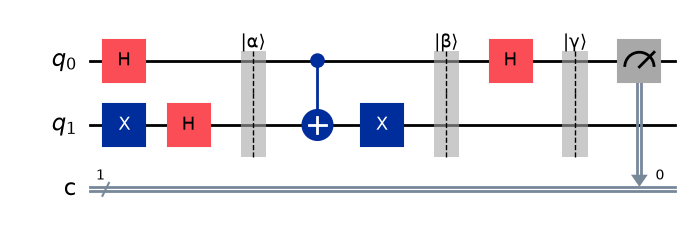

In [56]:
#Run simulated version of the quantum circuit just built
#Deutsch's algorithm returns function type with probability 1. So one measurement is enough (one shot)
result = AerSimulator().run(qc, shots = 1).result() 

pi1 = result.data()["|α⟩"]
pi2 = result.data()["|β⟩"]
pi3 = result.data()["|γ⟩"]

display(pi1.draw("latex"))
display(pi2.draw("latex"))
display(pi3.draw("latex"))

qc.draw('mpl')